In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [15]:
def get_fred_rates(api_key):
    fred_series = {
        'GS1': '1Y',
        'GS2': '2Y',
        'GS3': '3Y',
        'GS5': '5Y',
        'GS7': '7Y',
        'GS10': '10Y',
    }#spot
        
    if api_key:
    
        from fredapi import Fred
        fred = Fred(api_key=api_key)
        
        df = pd.DataFrame()
        for code, name in fred_series.items():
            data = fred.get_series(code)
            if not data.empty:
                df[name] = data
        
    return df

In [16]:
#Step 1: get the data, check and clean
rates = get_fred_rates('7de2d88d053d5772a2dde00bd4a5e100')
rates.describe()

,1Y,2Y,3Y,5Y,7Y,10Y
count,876.000000,598.000000,876.000000,876.000000,681.000000,876.000000
mean,4.631541,4.964498,4.998470,5.229532,5.815330,5.528493
std,3.240620,3.669923,3.139888,3.034187,3.192944,2.873032
min,0.050000,0.120000,0.160000,0.270000,0.460000,0.620000
25%,2.260000,1.717500,2.697500,2.957500,3.250000,3.555000
50%,4.385000,4.650000,4.535000,4.690000,5.840000,4.730000
75%,6.270000,7.125000,6.810000,6.965000,7.750000,7.330000
max,16.720000,16.460000,16.220000,15.930000,15.650000,15.320000


In [17]:
rates

,1Y,2Y,3Y,5Y,7Y,10Y
1953-04-01,2.36,NaN,2.51,2.62,NaN,2.83
1953-05-01,2.48,NaN,2.72,2.87,NaN,3.05
1953-06-01,2.45,NaN,2.74,2.94,NaN,3.11
1953-07-01,2.38,NaN,2.62,2.75,NaN,2.93
1953-08-01,2.28,NaN,2.58,2.80,NaN,2.95
...,...,...,...,...,...,...
2025-11-01,3.66,3.55,3.56,3.67,3.86,4.09
2025-12-01,3.54,3.50,3.55,3.70,3.90,4.14
2026-01-01,3.51,3.54,3.61,3.78,3.99,4.21
2026-02-01,3.48,3.47,3.52,3.68,3.89,4.13


<Axes: >

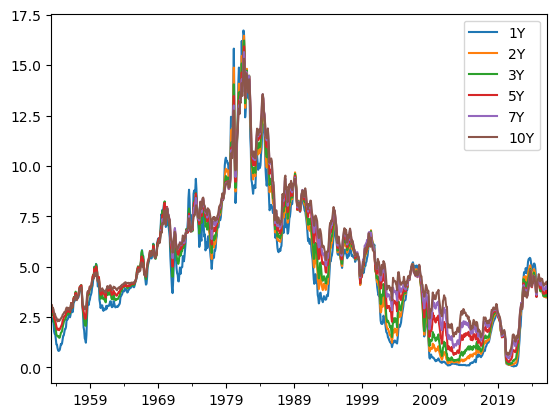

In [18]:
rates.plot()

<Axes: >

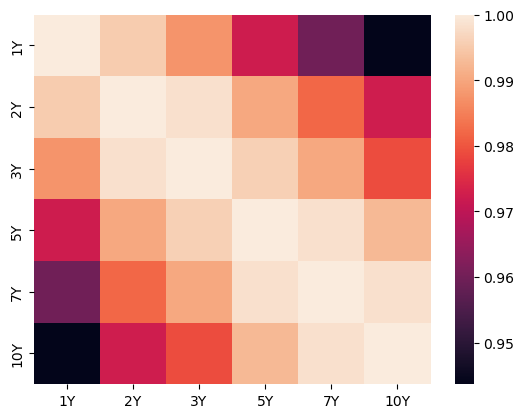

In [19]:
import seaborn as sns
sns.heatmap(rates.corr())
#Based on historical data, there are many missing values for the 2Y and 7Y maturities. The 1Y, 3Y, 5Y, and 10Y maturities show similar trends and movements to these two maturities and have high correlations with them.

In [20]:
rates.isna().sum()

1Y       0
2Y     278
3Y       0
5Y       0
7Y     195
10Y      0
dtype: int64

In [ ]:
#interpolate missing values
def predict_row_with_regression(row, maturity_map, min_points=2):
    """
    Fill missing values in a single yield curve (row) using linear regression.

    This function fits a cross-sectional linear regression model using the 
    available (non-missing) maturity-yield pairs in the row, and predicts 
    missing yields based on the fitted relationship.

    Parameters:
    - row (pd.Series): A single row representing a yield curve observation
    - maturity_map (dict): Mapping from column names to maturity values 
    - min_points (int, optional): Minimum number of observed data points required to fit the regression model. Default is 2.

    Returns:
    - pd.Series: A new row with missing values filled where possible
    """

    X = []  # maturities (independent variable)
    y = []  # yields (dependent variable)

    # Collect available data points
    for col, mat in maturity_map.items():
        if not pd.isna(row[col]):
            X.append([mat])
            y.append(row[col])

    # If insufficient data, return the original row
    if len(X) < min_points:
        return row

    # Fit linear regression model
    model = LinearRegression()
    model.fit(X, y)

    # Predict missing values
    new_row = row.copy()
    for col, mat in maturity_map.items():
        if pd.isna(row[col]):
            new_row[col] = model.predict([[mat]])[0]

    return new_row


def fill_missing_with_regression(df, maturity_map, min_points=2):
    return df.apply(lambda row: predict_row_with_regression(row, maturity_map, min_points),axis=1)

In [22]:
maturity_map = {
    '1Y': 1,
    '2Y': 2,
    '3Y': 3,
    '5Y': 5,
    '7Y': 7,
    '10Y': 10
}

rates = fill_missing_with_regression(rates, maturity_map)

In [23]:
rates

,1Y,2Y,3Y,5Y,7Y,10Y
1953-04-01,2.36,2.440503,2.51,2.62,2.694134,2.83
1953-05-01,2.48,2.615922,2.72,2.87,2.914246,3.05
1953-06-01,2.45,2.620726,2.74,2.94,2.964860,3.11
1953-07-01,2.38,2.512682,2.62,2.75,2.798715,2.93
1953-08-01,2.28,2.460615,2.58,2.80,2.809497,2.95
...,...,...,...,...,...,...
2025-11-01,3.66,3.550000,3.56,3.67,3.860000,4.09
2025-12-01,3.54,3.500000,3.55,3.70,3.900000,4.14
2026-01-01,3.51,3.540000,3.61,3.78,3.990000,4.21
2026-02-01,3.48,3.470000,3.52,3.68,3.890000,4.13


In [24]:
rates.describe()

,1Y,2Y,3Y,5Y,7Y,10Y
count,876.000000,876.000000,876.000000,876.000000,876.000000,876.000000
mean,4.631541,4.855535,4.998470,5.229532,5.395028,5.528493
std,3.240620,3.208646,3.139888,3.034187,2.962964,2.873032
min,0.050000,0.120000,0.160000,0.270000,0.460000,0.620000
25%,2.260000,2.537500,2.697500,2.957500,3.272500,3.555000
50%,4.385000,4.504469,4.535000,4.690000,4.740531,4.730000
75%,6.270000,6.640000,6.810000,6.965000,7.162500,7.330000
max,16.720000,16.460000,16.220000,15.930000,15.650000,15.320000


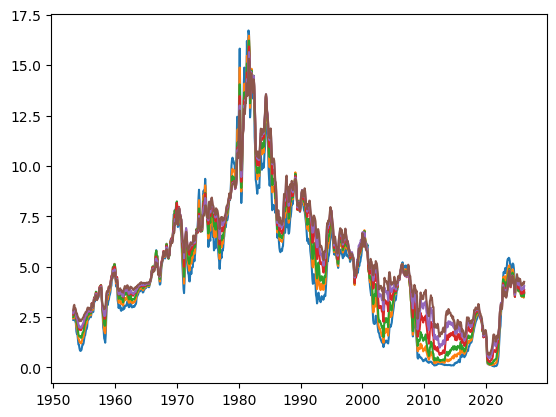

In [25]:
plt.plot(rates)

In [26]:
#Step 2 : calculate monthly change
rates_change_m = rates.diff().dropna()
rates_change_m = rates
rates_change_m

,1Y,2Y,3Y,5Y,7Y,10Y
1953-04-01,2.36,2.440503,2.51,2.62,2.694134,2.83
1953-05-01,2.48,2.615922,2.72,2.87,2.914246,3.05
1953-06-01,2.45,2.620726,2.74,2.94,2.964860,3.11
1953-07-01,2.38,2.512682,2.62,2.75,2.798715,2.93
1953-08-01,2.28,2.460615,2.58,2.80,2.809497,2.95
...,...,...,...,...,...,...
2025-11-01,3.66,3.550000,3.56,3.67,3.860000,4.09
2025-12-01,3.54,3.500000,3.55,3.70,3.900000,4.14
2026-01-01,3.51,3.540000,3.61,3.78,3.990000,4.21
2026-02-01,3.48,3.470000,3.52,3.68,3.890000,4.13


In [27]:
# Step 3: Standardize
scaler = StandardScaler()
X = scaler.fit_transform(rates_change_m)
X

array([[-0.70135913, -0.75309394, -0.79298757, -0.8605345 , -0.91207214,
        -0.9397857 ],
       [-0.66430803, -0.69839198, -0.72606799, -0.77809304, -0.83774201,
        -0.86316781],
       [-0.6735708 , -0.69689377, -0.7196947 , -0.75500943, -0.82064985,
        -0.84227202],
       ...,
       [-0.34628609, -0.4102311 , -0.44245644, -0.47800612, -0.47446764,
        -0.45918257],
       [-0.35554887, -0.43205963, -0.47113626, -0.51098271, -0.50823691,
        -0.48704362],
       [-0.29688462, -0.35721898, -0.40421667, -0.45492252, -0.457583  ,
        -0.44525204]])

# Method 1: PCA is implemented using the sklearn library on standardized yield changes.

In [28]:
# Apply PCA
pca = PCA()
pca.fit(X)

#1. explained variance(eigenvalues)
explained_var = np.round(pca.explained_variance_ratio_ , 3)
explained_var
#retain the first three principal components, which together explain almost all of the total variation in monthly yield changes.

array([0.986, 0.013, 0.001, 0.   , 0.   , 0.   ])

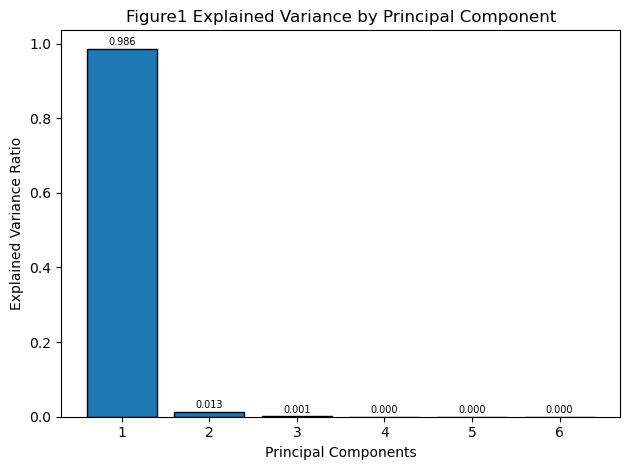

In [29]:
plt.bar(range(1,7), explained_var,edgecolor='black')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Figure1 Explained Variance by Principal Component')
for i, v in enumerate(explained_var, start=1):
    plt.text(i, v+0.01, f"{v:.3f}", ha='center', fontsize=7)
# save fig
plt.tight_layout()
plt.savefig('Figure1 scree_plot.png', dpi=300, bbox_inches='tight')

In [30]:
#2. loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=rates_change_m.columns,
    columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])]
)

loadings.iloc[:, :3]

,PC1,PC2,PC3
1Y,0.404236,0.630999,0.565508
2Y,0.409280,0.333421,-0.197287
3Y,0.410649,0.135316,-0.522379
5Y,0.410574,-0.170547,-0.352507
7Y,0.408763,-0.378597,0.027194
10Y,0.405947,-0.547666,0.493353


The table above reports the loadings of the first three principal components(eigenvectors). In PCA, these loadings correspond to the eigenvectors of the covariance (or correlation) matrix. Each column represents one principal component, while each row corresponds to a maturity of the Treasury yield curve.

Geometrically, each principal component can be viewed as a new axis in the transformed coordinate system. 
The loadings describe the direction of this axis by showing how each maturity contributes to it.

For example, the first principal component can be written as

PC1 = 0.40 · 1Y + 0.41 · 2Y + 0.41 · 3Y + 0.41 · 5Y + 0.41 · 7Y + 0.41 · 10Y

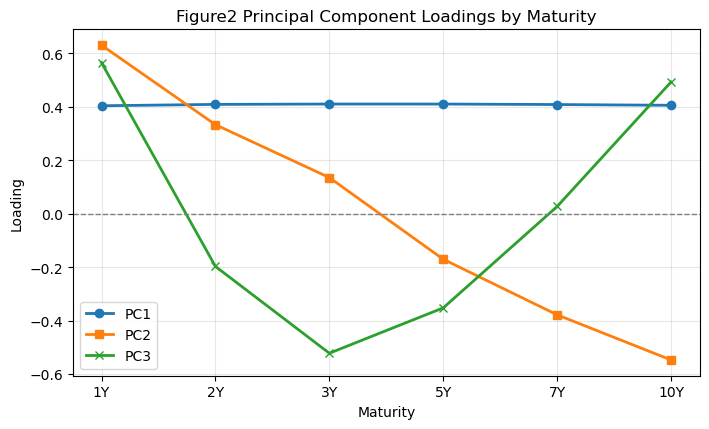

In [31]:
plt.figure(figsize=(7,4))
PC1 = loadings.iloc[:, :1]
PC2 = loadings.iloc[:, 1:2]
PC3 = loadings.iloc[:, 2:3]
plt.plot(PC1,label='PC1',marker='o',linewidth=2)
plt.plot(PC2,label='PC2',marker='s',linewidth=2)
plt.plot(PC3,label='PC3',marker='x',linewidth=2)
plt.axhline(0,color='grey',linestyle='--',linewidth=1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.xlabel('Maturity')
plt.ylabel('Loading')
plt.title('Figure2 Principal Component Loadings by Maturity')
plt.savefig('Figure2 PC_loadings_by_maturity.png', dpi=300, bbox_inches='tight')

## Interpretation of Principal Component Loadings
- PC1
The first principal component (PC1) exhibits nearly identical positive loadings across all maturities. This pattern indicates that all yields move in the same direction when this factor changes. Therefore, PC1 represents a level factor, capturing parallel shifts in the yield curve. When the level factor increases, interest rates across short-, medium-, and long-term maturities rise simultaneously.

- PC2
The second principal component (PC2) shows positive loadings for short-term maturities and negative loadings for long-term maturities. This opposite movement between the short end and the long end of the curve reflects changes in the steepness of the yield curve. As a result, PC2 can be interpreted as a slope factor, representing steepening or flattening of the yield curve.

- PC3
The third principal component (PC3) exhibits a curvature pattern. Loadings are positive at the short and long ends of the curve but negative for medium-term maturities. This indicates that medium-term yields move differently relative to both short- and long-term yields. Consequently, PC3 captures curvature changes in the yield curve, often associated with hump-shaped movements.

Overall, the loading patterns confirm the well-known three-factor representation of the yield curve: level, slope, and curvature.

In [32]:
# 3. Data Projection
scores = pd.DataFrame(
    pca.transform(X),
    index=rates_change_m.index,
    columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])]
)

scores[['PC1', 'PC2','PC3']].head() #projection of data onto PC axes

,PC1,PC2,PC3
1953-04-01,-2.025018,0.205800,-0.018914
1953-05-01,-1.864837,0.172311,-0.032951
1953-06-01,-1.840404,0.145976,-0.039177
1953-07-01,-1.952740,0.182189,-0.035143
1953-08-01,-1.966015,0.147563,-0.045019


Each row corresponds to a specific date, and the three values represent the coordinates of that observation in the PCA factor space:
- PC1: level factor
- PC2: slope factor
- PC3: curvature factor
 
[-2.02,0.20,-0.02]means that at that time point the yield curve movement can be described by a combination of:
- a negative level shift
- a small positive slope change
- a very small curvature change

Thus, the original 6-dimensional yield data is now represented by three factors.

## Data projection
Data projection transforms the standardized yield changes into the PCA coordinate system. Each observation is represented by its scores on the principal components, which measure the strength of level, slope, and curvature movements at each point in time.

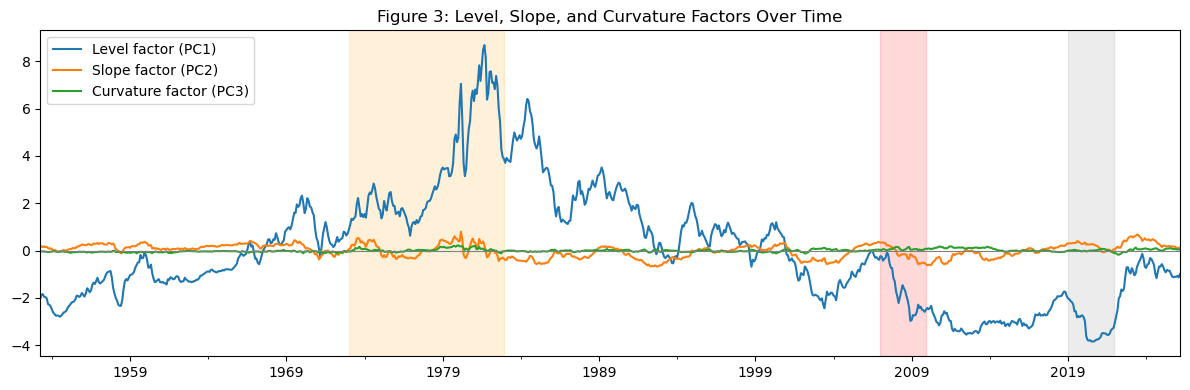

In [33]:
import matplotlib.pyplot as plt

scores[['PC1', 'PC2','PC3']].plot(
    figsize=(12, 4),
    title='Figure 3: Level, Slope, and Curvature Factors Over Time',
)

plt.axhline(0, color='grey', linewidth=0.8)

# 1973–1982 Oil Shock period (First Oil Shock (1973–1974), Second Oil Shock (1979–1980))
plt.axvspan('1973-01-01','1982-12-31',
           color='orange',alpha=0.15,label='Oil Shock Period')

# 2007–2009 Global Financial Crisis
plt.axvspan('2007-01-01', '2009-12-31',
            color='red', alpha=0.15, label='2008 Financial Crisis')

# 2019–2021 COVID-19 period
plt.axvspan('2019-01-01', '2021-12-31',
            color='gray', alpha=0.15, label='COVID-19 Period')

plt.legend(['Level factor (PC1)', 'Slope factor (PC2)','Curvature factor (PC3)'])
plt.tight_layout()
plt.savefig('Figure3 Level, Slope and Curvature Factor Over Time', dpi=300, bbox_inches='tight')
plt.show()

## Principal Factors over time analysis
Figure 3 plots the time series of the level (PC1), slope (PC2), and curvature (PC3) factors. 

The level factor shows much larger fluctuations than the other components, indicating that parallel shifts across maturities drive most movements in Treasury yields. The slope factor captures changes in the steepness of the yield curve, reflecting differences between short-term and long-term interest rate movements. Meanwhile, the curvature factor represents changes in the relative movement of medium-term yields compared with the short and long ends of the curve.

Significant movements in the level factor can be observed during periods of major macroeconomic stress. In particular, the late 1970s and early 1980s correspond to a period of persistent high inflation, oil price shocks, and strong monetary tightening by the Federal Reserve. Additional spikes appear during the 2007–2009 global financial crisis and the COVID-19 pandemic, when large economic shocks caused synchronized movements in Treasury yields across maturities.

# Method 2: PCA using Eigenvalue Decomposition

In [34]:
x_standard = pd.DataFrame(X,index=rates_change_m.index,columns=rates_change_m.columns)
x_standard

,1Y,2Y,3Y,5Y,7Y,10Y
1953-04-01,-0.701359,-0.753094,-0.792988,-0.860534,-0.912072,-0.939786
1953-05-01,-0.664308,-0.698392,-0.726068,-0.778093,-0.837742,-0.863168
1953-06-01,-0.673571,-0.696894,-0.719695,-0.755009,-0.820650,-0.842272
1953-07-01,-0.695184,-0.730586,-0.757934,-0.817665,-0.876756,-0.904959
1953-08-01,-0.726060,-0.746822,-0.770681,-0.801177,-0.873115,-0.897994
...,...,...,...,...,...,...
2025-11-01,-0.299972,-0.407113,-0.458390,-0.514280,-0.518368,-0.500974
2025-12-01,-0.337023,-0.422705,-0.461576,-0.504387,-0.504860,-0.483561
2026-01-01,-0.346286,-0.410231,-0.442456,-0.478006,-0.474468,-0.459183
2026-02-01,-0.355549,-0.432060,-0.471136,-0.510983,-0.508237,-0.487044


<Axes: >

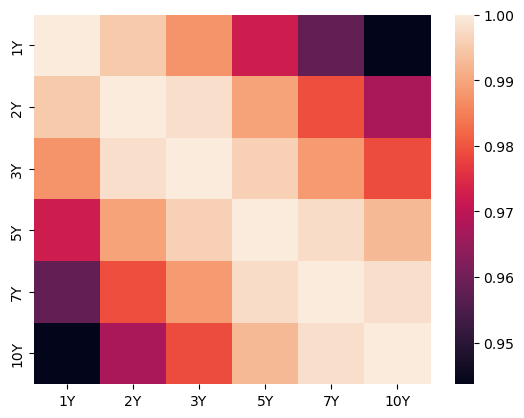

In [35]:
sns.heatmap(x_standard.corr())

In [36]:
mu = rates_change_m.mean()
sigma = rates_change_m.std()
x_standard = (rates_change_m-mu)/sigma
corr_matrix_dt = x_standard.cov()
corr_matrix_dt

,1Y,2Y,3Y,5Y,7Y,10Y
1Y,1.000000,0.995050,0.987509,0.972148,0.958008,0.943638
2Y,0.995050,1.000000,0.998096,0.989433,0.979222,0.967520
3Y,0.987509,0.998096,1.000000,0.995993,0.988521,0.978966
5Y,0.972148,0.989433,0.995993,1.000000,0.997767,0.992592
7Y,0.958008,0.979222,0.988521,0.997767,1.000000,0.998154
10Y,0.943638,0.967520,0.978966,0.992592,0.998154,1.000000


In [37]:
eigenvalues, eigenvectors = np.linalg.eig(corr_matrix_dt)

In [38]:
PC_index = ["PC1","PC2","PC3","PC4","PC5","PC6"]
df_eigval = pd.DataFrame({"Eigenvalues":eigenvalues}, index = PC_index )
df_eigval

,Eigenvalues
PC1,5.914406
PC2,0.080984
PC3,0.003986
PC4,0.000081
PC5,0.000312
PC6,0.000231


In [39]:
# Work out explained proportion 
df_eigval["Explained proportion"] = df_eigval["Eigenvalues"] / np.sum(df_eigval["Eigenvalues"])
#Format as row number
df_eigval.style.format({"Explained proportion": '{.2f%}'})
df_eigval

,Eigenvalues,Explained proportion
PC1,5.914406,0.985734
PC2,0.080984,0.013497
PC3,0.003986,0.000664
PC4,0.000081,0.000014
PC5,0.000312,0.000052
PC6,0.000231,0.000038


In [40]:
eigenvectors_dt = pd.DataFrame(eigenvectors, columns = ["PC1","PC2","PC3","PC4","PC5","PC6"], index = corr_matrix_dt.columns )
eigenvectors_dt

,PC1,PC2,PC3,PC4,PC5,PC6
1Y,0.404236,-0.630999,0.565508,0.164486,0.270895,0.134886
2Y,0.409280,-0.333421,-0.197287,-0.595203,-0.420370,-0.389129
3Y,0.410649,-0.135316,-0.522379,0.652023,-0.306115,0.146074
5Y,0.410574,0.170547,-0.352507,-0.391690,0.494986,0.528819
7Y,0.408763,0.378597,0.027194,0.198483,0.433035,-0.679649
10Y,0.405947,0.547666,0.493353,-0.026983,-0.472937,0.259757


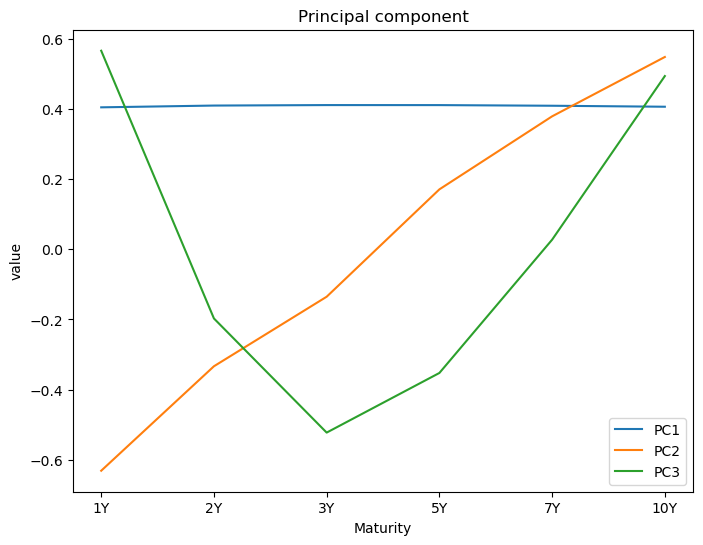

In [41]:
plt.figure(figsize=(8, 6))
for t in ["PC1","PC2","PC3"]:
    PC = eigenvectors_dt[t]
    display(plt.plot(PC, label = t))
    plt.xlabel("Maturity")
    plt.ylabel("value")
    plt.legend()
    plt.title("Principal component")

In [42]:
# Rolling Window Stability testing
window = 60  
rolling_explained = []
rolling_dates = []

for i in range(window, len(rates_change_m)):
    window_data = rates_change_m.iloc[i-window:i]
    
    # standardize each window
    X_win = StandardScaler().fit_transform(window_data)
    
    # PCA
    pca_win = PCA(n_components=3)
    pca_win.fit(X_win)
    
    rolling_explained.append(pca_win.explained_variance_ratio_)
    rolling_dates.append(rates_change_m.index[i])
    
rolling_explained = np.array(rolling_explained)

rolling_df = pd.DataFrame(
    rolling_explained,
    index=rolling_dates,
    columns=['PC1', 'PC2','PC3']
)


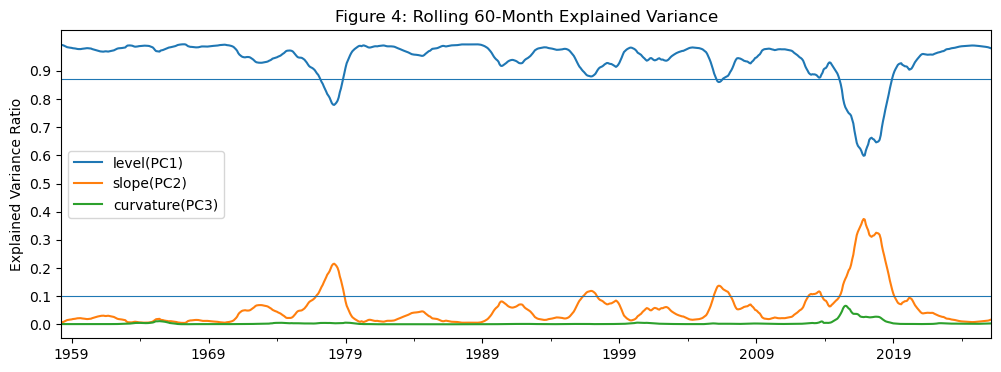

In [43]:
rolling_df.plot(
    figsize=(12,4),
    title='Figure 4: Rolling 60-Month Explained Variance'
)

plt.ylabel('Explained Variance Ratio')
plt.legend(['level(PC1)','slope(PC2)','curvature(PC3)'])
plt.gca().set_yticks(np.arange(0, 1.0, 0.1)) 
plt.axhline(0.87, linewidth=0.8)
plt.axhline(0.10, linewidth=0.8)
plt.savefig('Figure4 Rolling 60-Month Explained Variance.png')
plt.show()

## Rolling Window Analysis Interpretation
Figure 4 presents the explained variance ratios of the first three principal components estimated using a rolling 60-month window. The level factor (PC1) consistently explains the majority of yield curve variation, remaining close to 90% throughout most of the sample. In contrast, the slope factor (PC2) accounts for a smaller share of the variance, typically around 10%, while the curvature factor (PC3) contributes only a minimal portion.

Although the relative importance of the factors fluctuates during periods of market stress—most notably around the global financial crisis—the dominance of the level factor remains stable over time. Overall, the results suggest that the three-factor representation of the yield curve is relatively stable.

In [44]:
#Reconstruction Test

# Use the first three principal component scores(Time x Factor)
pcs = scores[['PC1','PC2','PC3']].values

# PCA loadings corresponding to the first three components(Factor x Maturity)
loadings_3 = pca.components_[:3]

# Reconstruct the standardized data using PC scores and loadings(Time x Maturity)
X_reconstructed = np.dot(pcs, loadings_3)

# Convert the reconstructed array back to a DataFrame
reconstructed_df = pd.DataFrame(
    X_reconstructed,
    index=rates_change_m.index,
    columns=rates_change_m.columns
)

# If the data were standardized earlier, apply inverse transformation
# to convert the reconstructed data back to the original scale
reconstructed_original_scale = pd.DataFrame(
    scaler.inverse_transform(reconstructed_df),
    index=rates_change_m.index,
    columns=rates_change_m.columns
)

In [45]:
X_reconstructed

array([[-0.69942028, -0.75644974, -0.79384286, -0.85985015, -0.90618158,
        -0.94409139],
       [-0.66373904, -0.69928763, -0.72526388, -0.78342461, -0.82840851,
        -0.86765072],
       [-0.67400064, -0.69683993, -0.71554157, -0.76670703, -0.80862039,
        -0.84638149],
       ...,
       [-0.34386646, -0.41280162, -0.44829622, -0.47033619, -0.47148724,
        -0.46385137],
       [-0.35263565, -0.43524698, -0.47770869, -0.50297033, -0.50329318,
        -0.49316417],
       [-0.2908801 , -0.36762721, -0.40908383, -0.44272127, -0.45277312,
        -0.45299758]])

In [46]:
reconstructed_df

,1Y,2Y,3Y,5Y,7Y,10Y
1953-04-01,-0.699420,-0.756450,-0.793843,-0.859850,-0.906182,-0.944091
1953-05-01,-0.663739,-0.699288,-0.725264,-0.783425,-0.828409,-0.867651
1953-06-01,-0.674001,-0.696840,-0.715542,-0.766707,-0.808620,-0.846381
1953-07-01,-0.694279,-0.731538,-0.758879,-0.820427,-0.868140,-0.909826
1953-08-01,-0.727079,-0.746569,-0.763857,-0.816491,-0.860725,-0.901124
...,...,...,...,...,...,...
2025-11-01,-0.297924,-0.407978,-0.466230,-0.506615,-0.513610,-0.506754
2025-12-01,-0.335044,-0.423441,-0.469225,-0.497564,-0.499193,-0.489660
2026-01-01,-0.343866,-0.412802,-0.448296,-0.470336,-0.471487,-0.463851
2026-02-01,-0.352636,-0.435247,-0.477709,-0.502970,-0.503293,-0.493164


In [47]:
reconstructed_original_scale

,1Y,2Y,3Y,5Y,7Y,10Y
1953-04-01,2.366279,2.429741,2.507316,2.622075,2.711578,2.817637
1953-05-01,2.481843,2.613050,2.722523,2.853832,2.941885,3.037128
1953-06-01,2.448608,2.620899,2.753033,2.904528,3.000483,3.098200
1953-07-01,2.382930,2.509627,2.617035,2.741623,2.824230,2.916025
1953-08-01,2.276698,2.461429,2.601413,2.753560,2.846186,2.941013
...,...,...,...,...,...,...
2025-11-01,3.666634,3.547225,3.535398,3.693246,3.874089,4.073403
2025-12-01,3.546412,3.497640,3.525998,3.720690,3.916782,4.122486
2026-01-01,3.517837,3.531757,3.591674,3.803259,3.998826,4.196594
2026-02-01,3.489435,3.459779,3.499375,3.704297,3.904640,4.112425


In [48]:
# Compute reconstruction error using RMSE (Root Mean Squared Error)
rmse = np.sqrt(((rates_change_m - reconstructed_original_scale) ** 2).mean())

print("Reconstruction RMSE by maturity:")
print(rmse)

Reconstruction RMSE by maturity:
1Y     0.017538
2Y     0.034977
3Y     0.026028
5Y     0.037574
7Y     0.038422
10Y    0.026549
dtype: float64


The results show that the reconstruction errors are very small (around 0.02–0.04 across maturities), indicating that the **three-factor representation (level, slope, and curvature) captures most of the variation in the yield curve movements**.

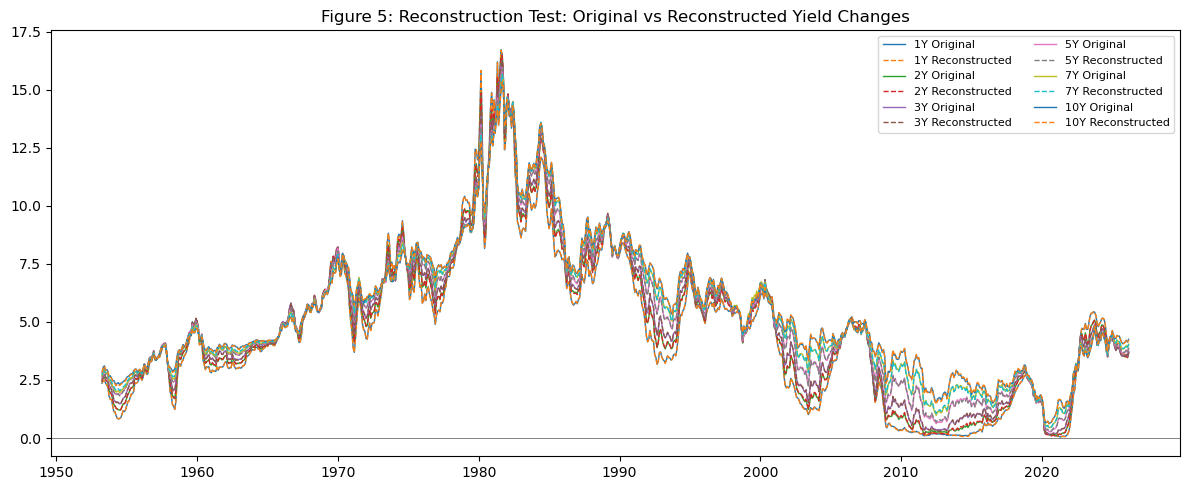

In [49]:
plt.figure(figsize=(12,5))

for maturity in rates_change_m.columns:
    
    # original
    plt.plot(
        rates_change_m.index,
        rates_change_m[maturity],
        linewidth=1,
        label=f'{maturity} Original'
    )
    
    # reconstructed
    plt.plot(
        reconstructed_original_scale.index,
        reconstructed_original_scale[maturity],
        linestyle='--',
        linewidth=1,
        label=f'{maturity} Reconstructed'
    )

plt.axhline(0,color='grey',linewidth=0.7)

plt.title('Figure 5: Reconstruction Test: Original vs Reconstructed Yield Changes')

plt.legend(ncol=2,fontsize=8)

plt.tight_layout()

plt.savefig('Figure5_Reconstruction_All_Maturities.png',dpi=300,bbox_inches='tight')

plt.show()

## Reconstruction Test Interpretation
Figure 5 compares the original and reconstructed yield changes using the first three principal components. The reconstructed series closely tracks the original data across all maturities, indicating that the three-factor representation captures most of the variation in the yield curve. This result further confirms that the level, slope, and curvature factors provide a stable and effective summary of yield curve dynamics.